In [115]:
import numpy as np
from collections import deque
import time

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.colors import ListedColormap
from scipy.integrate import solve_bvp
import moviepy.editor as mp


In [116]:
def Ghost_Solver(pacman_state, ghost_state, K, M, x_board_max, y_board_max, smart=False):
    """ Returns the solution to solve bvp where the first four
    rows are xg, yg, xg_vel, and yg_vel, and the last four rows
    are the costate.

    Parameters:
        pacman_state (tuple): (xp, yp, xp_vel, yp_vel)
        ghost_state (tuple):  (xg, yg, xg_vel, yg_vel)
        K (int): penalty on squared acceleration of ghost
        M (int): weight on 1/x term to raise penalty close to borders
        x_board_max(int): The x coordinate of the board in the plot
        y_board_max(int): The y coordinate of the board in the plot
        smart (bool): Converges to pacmans current position if false,
            converges to pacmans predicted position if true.
    Returns:
        sol (ndarray (8, 50)) The y part of the solution of bvp.
    """
    # Break apart the states
    xp, yp, xp_vel, yp_vel = pacman_state
    xg, yg, xg_vel, yg_vel = ghost_state

    # Get the target point
    if smart:
        x_target = xp + xp_vel
        y_target = yp + yp_vel
    else:
        x_target = xp
        y_target = yp

    # define the ode
    def ode(t, y):
        xg_pos = y[0]
        yg_pos = y[1]
        xg_vel = y[2]
        yg_vel = y[3]
        lam1 = y[4]
        lam2 = y[5]
        lam3 = y[6]
        lam4 = y[7]
        lam1_prime = 2*(xg_pos - x_target) - M * (x_board_max-2*xg_pos) / (xg_pos**2 * (x_board_max-xg_pos)**2)
        lam2_prime = 2*(yg_pos - y_target) - M * (y_board_max-2*yg_pos) / (yg_pos**2 * (y_board_max-yg_pos)**2)
        return np.vstack((xg_vel, yg_vel, .5*(1/K)*lam3, .5*(1/K)*lam4,
                          lam1_prime, lam2_prime, -lam1, -lam2))

    # define the boundary conditions
    def bcs(ya, yb):
        return np.array([ya[0]-xg, ya[1]-yg, ya[2]-xg_vel, ya[3]-yg_vel,
                         yb[4], yb[5], yb[6], yb[7]])

    # define H
    # initial condtions
    t = np.linspace(0, 1, 50)
    y_guess = np.vstack([
        xg * np.ones_like(t),
        yg * np.ones_like(t),
        xg_vel * np.ones_like(t),
        yg_vel * np.ones_like(t),
        np.zeros_like(t),
        np.zeros_like(t),
        np.zeros_like(t),
        np.zeros_like(t)
    ])
    # solve it
    sol = solve_bvp(ode, bcs, t, y_guess)
    return sol.y

# Master Pac-Man

In [117]:
class Pacman:
    """
    A discrete optimal control environment for a naive Pacman game.
    """
    def __init__(self, weights, num_ghosts=1, solver_K=2, solver_M=1,
                 smart_solver=False, big=True, random_start=False, ):
        """
        Initializes the game state, extracts entity positions, and sets up the board.

        Parameters:
            - weights (ndarray): A positive 5-element array for the cost functional weights.
                w1: Reward small distance to pellet
                w2: Reward eating a pellet
                w2: Reward large distance to ghost
                w4: Penalize really close to ghost
                w5: Penalize time spent playing

            - num_ghosts (int): Number of ghosts to include (1 <= num_ghosts <= 4)
            - solver_K (int): penalty on squared acceleration of ghost (put in solver)
            - solver_M (int): weight on 1/x term to raise penalty close to borders (put in solver)
            - smart_solver (bool): solver Converges to pacmans current position if false,
                converges to pacmans predicted position if true.
            - big (bool): Uses standard board if True, otherwise uses smaller 10x10 board
            - random_start (bool): Randomly initializes pacman and ghosts if true,
                otherwise starts each in predetermined spot
        """

        self.weights = np.array(weights)
        self.solver_K = solver_K
        self.solver_M = solver_M
        self.smart_solver = smart_solver
        self.k = 0

        # Load the raw start board
        if big:
            raw_board = self._generate_big_start_board()
            self.board = np.copy(raw_board)
            pacman_pos = (23, 13)
            self.figsize = (12, 14)
        else:
            raw_board = self._generate_small_start_board()
            self.board = np.copy(raw_board)
            pacman_pos = (5, 4)
            self.figsize = (6, 6)

        self.rows, self.cols = self.board.shape

        default_ghost_locations = [
            (1.0, 1.0),
            (1.0, float(self.cols - 2)),
            (float(self.rows - 2), float(self.cols - 2)),
            (float(self.rows - 2), 1.0),
        ]

        # Set the ghosts location:
        # Raise an error if num_ghosts is outside of [1, 4]
        if num_ghosts > 4 or num_ghosts < 1:
            raise ValueError(f'{num_ghosts} must be between 1 and 4')

        ghost_poss = []
        for i in range(num_ghosts):
            ghost_poss.append(default_ghost_locations[i])


        # Randomize the positions of the players if random_start is True
        if random_start:
            # Randomize pacman position, but make sure it is legal
            while True:
                p_row = np.random.randint(self.rows)
                p_col = np.random.randint(self.cols)
                if self.board[p_row, p_col] == 2:
                    break

            pacman_pos = (p_row, p_col)

            # Randomize the ghost position (but it can be anywhere on the board)
            new_ghost_poss = []
            for _ in range(num_ghosts):
                g_row = np.random.random() * (self.rows - 1)
                g_col = np.random.random() * (self.cols - 1)
                new_ghost_poss.append((g_row, g_col))

            ghost_poss = new_ghost_poss

        # Save the positions and the states of pacman and ghosts
        self.pacman_pos = pacman_pos
        self.pacman_state = (pacman_pos[1], pacman_pos[0], 0, 0)

        self.ghost_poss = ghost_poss
        self.ghost_states = []
        for g_pos in ghost_poss:
            self.ghost_states.append((g_pos[1], g_pos[0], 0.0, 0.0))

        # Set the pacman_pos location = 0 (no pellet)
        self.board[self.pacman_pos[0]][self.pacman_pos[1]] = 0

        # Initialize a list of history for saving the animation
        self.history = []


    def _generate_small_start_board(self):
        """
        Returns a 10x10 numpy array for testing optimal control algorithms.

        Legend:
        0 = Empty / Tunnel
        1 = Wall
        2 = Pellet
        """
        mini_str = [
            "1111111111",
            "1222222221",
            "1211221121",
            "1212222121",
            "1212112121",
            "1222222221",
            "1211221121",
            "1211221121",
            "1222222221",
            "1111111111"
        ]
        return np.array([[int(char) for char in row] for row in mini_str], dtype=np.int8)


    def _generate_big_start_board(self):
        """
        Returns a 31x28 numpy array representing the classic Pacman board.

        Legend:
        0 = Empty / Tunnel
        1 = Wall
        2 = Pellet
        """
        board_str = [
            "1111111111111111111111111111",
            "1222222222222112222222222221",
            "1211112111112112111112111121",
            "1211112111112112111112111121", # Power pellets
            "1211112111112112111112111121",
            "1222222222222222222222222221",
            "1211112112111111112112111121",
            "1211112112111111112112111121",
            "1222222112222112222112222221",
            "1111112111110110111112111111",
            "0000012111110110111112100000",
            "0000012110000000000112100000",
            "0000012110111111110112100000",
            "1111112110100000010112111111",
            "1111112000100000010002111111", # Tunnels & Ghost House (4 Ghosts)
            "1111112110100000010112111111",
            "0000012110111111110112100000",
            "0000012110000000000112100000",
            "0000012110111111110112100000",
            "1111112110111111110112111111",
            "1222222222222112222222222221",
            "1211112111112112111112111121",
            "1211112111112112111112111121",
            "1222112222222002222222112221", # Power pellets & Pacman
            "1112112112111111112112112111",
            "1112112112111111112112112111",
            "1222222112222112222112222221",
            "1211111111112112111111111121",
            "1211111111112112111111111121",
            "1222222222222222222222222221",
            "1111111111111111111111111111"
        ]
        return np.array([[int(char) for char in row] for row in board_str], dtype=np.int8)


    def distance_to_nearest_pellet(self, pos):
        """
        Return the integer distance between a given position and the nearest pellet.
        """
        rows, cols = self.board.shape
        queue = deque([(pos, 0)])
        visited = set([pos])

        while queue:
            (row, col), dist = queue.popleft()

            # Break if we found a pellet
            if self.board[row][col] == 2:
                return dist

            # Explore neighbors
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                neighbor = (row + dr, col + dc)

                if 0 <= neighbor[0] < rows and 0 <= neighbor[1] < cols:
                    if self.board[neighbor[0], neighbor[1]] != 1 and (neighbor[0], neighbor[1]) not in visited:
                        visited.add((neighbor[0], neighbor[1]))
                        queue.append(((neighbor[0], neighbor[1]), dist + 1))

        return 100 # Large penalty if no pellets are reachable

    def distance_to_nearest_ghost(self, pos):
        """
        Return the integer distance between a given position and the nearest ghost.
        (Implemented ignoring walls since ghosts can go through them).
        """
        # Initialize the nearest distance to infinity to save the smallest distance
        nearest_dist = 100

        for ghost_pos in self.ghost_poss:
            # Get the rounded position of the ghost
            ghost_row, ghost_col = round(ghost_pos[0]), round(ghost_pos[1])

            # Find the distance between the ghost and pos
            dist_array = np.array([ghost_row - pos[0], ghost_col - pos[1]])
            dist = np.linalg.norm(dist_array, ord=2)

            # Save the distance if it is lower
            if dist < nearest_dist:
                nearest_dist = dist

        return nearest_dist

    def _is_pellet(self, pos):
        """Returns True if the tuple pos is coordinates that represent a pellet."""
        return self.board[pos[0], pos[1]] == 2


    def get_ghost_states(self):
        """
        For each ghost in ghost_states, returns the states that would make the ghost
        move towards Pacman in the shortest path.
        Returns a list of states (tuples).
        """
        states = []

        ghosts_paths = []
        for g_state in self.ghost_states:
            sol = Ghost_Solver(self.pacman_state, g_state, self.solver_K, self.solver_M,
                               self.cols - 1, self.rows - 1, self.smart_solver)

            # Save the path the ghost took
            ghosts_paths.append(sol[:2, :])

            new_state = (sol[0, -1], sol[1, -1], sol[2, -1], sol[3, -1])

            states.append(new_state)

        self.ghosts_paths = ghosts_paths
        return states

    def get_ghost_shortest_path_move(self):
        """
        For each ghost in ghost_poss, returns the move that would make the ghost
        move towards Pacman in the shortest path.
        Returns a list of moves (tuples).
        """
        moves = []

        self.ghost_states = self.get_ghost_states()

        for state in self.ghost_states:
            move = state[1], state[0]
            moves.append(move)

        return moves


    def find_best_move(self):
        """
        Loops through all possible moves to evaluate the best control input 'u'.
        Evaluates J = w^T * f(x)
        """
        admissible_moves = [( -1, 0 ), ( 1, 0 ), ( 0, -1 ), ( 0, 1 )]
        best_u = (0, 0)

        # We want to maximize the reward so start at -inf
        max_reward = -np.inf

        for u in admissible_moves:
            # Get the next position
            next_pos = (self.pacman_pos[0] + u[0], self.pacman_pos[1] + u[1])

            # Reject if it's a wall
            if self.board[next_pos[0], next_pos[1]] == 1:
                continue

            # Get the features
            # Reward moving to nearest pellet and eating a pellet
            dist_pellet = - self.distance_to_nearest_pellet(next_pos)
            dist_ghost = self.distance_to_nearest_ghost(next_pos)
            ate_pellet = 1 if self._is_pellet(next_pos) else 0

            # Penalize moving to the nearest ghost and being adjacent to ghost
            ghost_adjacent = -1 if dist_ghost <= 2 else 0

            # Also penalize the timestep
            step_penalty = - self.k

            h = np.array([dist_pellet, ate_pellet, dist_ghost, ghost_adjacent, step_penalty])

            # Calculate Cost (J = w^T h)
            reward = np.dot(self.weights, h)

            # Check if optimal
            if reward > max_reward:
                max_reward = reward
                best_u = u

        return best_u

    def update_board(self, move, new_ghost_poss):
        """
        Updates the entity coordinates based on the optimal controls.
        """
        # Update Pacman
        new_pacman_pos = (self.pacman_pos[0] + move[0], self.pacman_pos[1] + move[1])
        if self.board[new_pacman_pos[0], new_pacman_pos[1]] != 1:
            self.pacman_pos = new_pacman_pos

            # Eat pellet
            if self._is_pellet(self.pacman_pos):
                self.board[self.pacman_pos[0], self.pacman_pos[1]] = 0

        # Update Pacman state
        self.pacman_state = (new_pacman_pos[1], new_pacman_pos[0], move[1], move[0])

        # Update Ghosts
        self.ghost_poss = new_ghost_poss

        # Increment timestep
        self.k += 1

    def play(self, plot=False):
        """
        Main simulation loop.
        """
        print("Starting Simulation...")

        # Save the initial state
        self.history.append({
            'board': np.copy(self.board),
            'pacman': self.pacman_pos,
            'ghosts': list(self.ghost_poss),
            'ghosts_paths': [np.array([[pos[1]], [pos[0]]]) for pos in self.ghost_poss]
        })

        # Check if there are any pellets left to eat (Total == 2s in array)
        while np.any(self.board == 2):

            # Print a status report every 25th time step
            if self.k % 25 == 0:
                pellets_left = np.sum(self.board == 2)
                print(f'At time {self.k}, there are {pellets_left} pellets left.')


            # Check terminal state (Death)
            rounded_ghost_poss = [(round(row), round(col)) for (row, col) in self.ghost_poss]
            if self.pacman_pos in rounded_ghost_poss:
                print("GAME OVER - Caught by Ghost!")
                break

            # Sense / Evaluate (Pacman's Turn)
            best_move = self.find_best_move()

            # Adversary (Ghost's Turn)
            new_ghost_poss = self.get_ghost_shortest_path_move()

            # Act / Update physics
            self.update_board(best_move, new_ghost_poss)

            if plot:
                self.plot_board()

            # Save the state after every move
            self.history.append({
                'board': np.copy(self.board),
                'pacman': self.pacman_pos,
                'ghosts': list(self.ghost_poss),
                'ghosts_paths' : self.ghosts_paths
            })

            # Delay for if plotting
            time.sleep(0.1)

        if not np.any(self.board == 2):
            print("YOU WIN! All pellets consumed.")

    def plot_board(self, filename="board.pdf"):
        """
        Generates and saves plot of the current state of the board.
        """
        fig, ax = plt.subplots(figsize=self.figsize)
        ax.set_axis_off() # Hide the axis ticks for a cleaner look

        # Create a custom color map for the board
        # 0: Empty (Black), 1: Wall (Blue), 2: Pellet (White)
        cmap = ListedColormap(['darkgrey', 'mediumblue', 'white'])

        # Initialize the base board image
        im = ax.imshow(self.board, cmap=cmap, vmin=0, vmax=2)

        # Initialize the scatter plots for entities
        # Note: scatter takes (x, y) which translates to (col, row)
        p_row, p_col = self.pacman_pos
        pacman_scatter = ax.scatter(p_col, p_row, c='yellow', s=250, marker='o', edgecolors='orange')

        # Plot the ghosts
        ghost_colors = ['red', 'pink', 'orange', 'cyan']
        ghost_scatters = []
        for i, (g_row, g_col) in enumerate(self.ghost_poss):
            ghost_scatter = ax.scatter(g_col, g_row, c=ghost_colors[i], s=250, marker='^', edgecolors='darkred')
            ghost_scatters.append(ghost_scatter)

        # # Test new position
        # ax.scatter(3, 5.5, c='cyan', s=250, marker='^', edgecolors='darkred')

        # #  Test path of ghost
        # total_path = self.history[0]['ghosts_paths'][0]
        # for state in self.history:
        #     path = state['ghosts_paths'][0]
        #     total_path = np.hstack((total_path, path))
        # plt.plot(total_path[0], total_path[1], c='red')

        # Add a title to show the timestep
        title = ax.set_title(f"Optimal Control Pacman - Timestep: {self.k}", color='black', fontsize=14)

        # Set background color of the figure to match
        fig.patch.set_facecolor('lightgray')

        # fig.savefig(filename)
        plt.show()


    def save_animation(self, filename="pacman_simulation", fps=4):
        """
        Generates and saves an MP4 animation of the recorded game history.
        """

        if not self.history:
            print("No history to animate! Run play() first.")
            return

        fig, ax = plt.subplots(figsize=self.figsize)
        ax.set_axis_off() # Hide the axis ticks for a cleaner look

        # Create a custom color map for the board
        # 0: Empty (Black), 1: Wall (Blue), 2: Pellet (White)
        cmap = ListedColormap(['darkgrey', 'mediumblue', 'white'])

        # Initialize the base board image
        initial_state = self.history[0]
        im = ax.imshow(initial_state['board'], cmap=cmap, vmin=0, vmax=2)

        # Initialize the scatter plots for entities
        # Note: scatter takes (x, y) which translates to (col, row)
        p_row, p_col = initial_state['pacman']
        pacman_scatter = ax.scatter(p_col, p_row, c='yellow', s=250, marker='o', edgecolors='orange')

        # Plot the ghosts
        ghost_colors = ['red', 'pink', 'orange', 'cyan']
        ghost_scatters = []
        for i, (g_row, g_col) in enumerate(initial_state['ghosts']):
            ghost_scatter = ax.scatter(g_col, g_row, c=ghost_colors[i], s=250, marker='^', edgecolors='darkred')
            ghost_scatters.append(ghost_scatter)

        # Plot the ghosts paths
        ghosts_lines = []
        for i, path in enumerate(initial_state['ghosts_paths']):
            ghost_line, = ax.plot(path[0], path[1], '--', c=ghost_colors[i], )
            ghosts_lines.append(ghost_line)

        # Add a title to show the timestep
        title = ax.set_title(f"Optimal Control Pacman - Timestep: {self.k}", color='black', fontsize=14)

        # Set background color of the figure to match
        fig.patch.set_facecolor('lightgray')

        total_paths = [np.empty((2, 0)) for _ in self.ghost_poss]

        def update(frame):
            """The function called by FuncAnimation to draw each frame."""
            state = self.history[frame]

            # Update walls and pellets
            im.set_data(state['board'])

            # Update Pacman
            pr, pc = state['pacman']
            pacman_scatter.set_offsets(np.c_[pc, pr])

            # Update Ghost
            if state['ghosts']:
                for scatter, (gr, gc) in zip(ghost_scatters, state['ghosts']):
                    scatter.set_offsets(np.c_[gc, gr])
            if state['ghosts_paths']:
                for i, (line, path) in enumerate(zip(ghosts_lines, state['ghosts_paths'])):
                    total_paths[i] = np.hstack((total_paths[i], path))
                    line.set_data(total_paths[i][0], total_paths[i][1])

            title.set_text(f"Optimal Control Pacman - Timestep: {frame}")

            return [im, pacman_scatter, ghost_scatter, title]

        print(f"Rendering {len(self.history)} frames to {filename}.mp4...")

        ani = FuncAnimation(
            fig, update, frames=len(self.history),
            interval=1000/fps, blit=True
        )

        writer = FFMpegWriter(fps=fps, metadata=dict(artist='Optimal Controller'), bitrate=1800)

        try:
            ani.save(filename + '.mp4', writer=writer)
            print(f"Animation successfully saved to {filename}.mp4")
        except Exception as e:
            print(f"Failed to save animation. Do you have ffmpeg installed?\nError: {e}")

        # Save the final state of the animation
        print(f"Final frame successfully saved to {filename}.png")
        fig.savefig(filename + '.png')
        # plt.close(fig) # Prevent the final frame from hanging around in memory

In [118]:
# Determine the weights
dist_pellet = 5
ate_pellet = 10
dist_ghost = 6
ghost_adjacent = 100
step_penalty = .5

# Declare the variables
w = np.array([dist_pellet, ate_pellet, dist_ghost, ghost_adjacent, step_penalty])
num_ghosts = 4
solver_K = 20
solver_M = 500
smart_solver = False
big = True
random_start = True

game = Pacman(w, num_ghosts, solver_K, solver_M, smart_solver, big, random_start)

Starting Simulation...
At time 0, there are 243 pellets left.
At time 25, there are 218 pellets left.
At time 50, there are 197 pellets left.
At time 75, there are 177 pellets left.
At time 100, there are 153 pellets left.
At time 125, there are 128 pellets left.
At time 150, there are 103 pellets left.
At time 175, there are 92 pellets left.
At time 200, there are 67 pellets left.
At time 225, there are 52 pellets left.
At time 250, there are 46 pellets left.
At time 275, there are 38 pellets left.
At time 300, there are 28 pellets left.
At time 325, there are 21 pellets left.
At time 350, there are 16 pellets left.
At time 375, there are 8 pellets left.
YOU WIN! All pellets consumed.
Rendering 387 frames to test.mp4...
Animation successfully saved to test.mp4
Final frame successfully saved to test.png


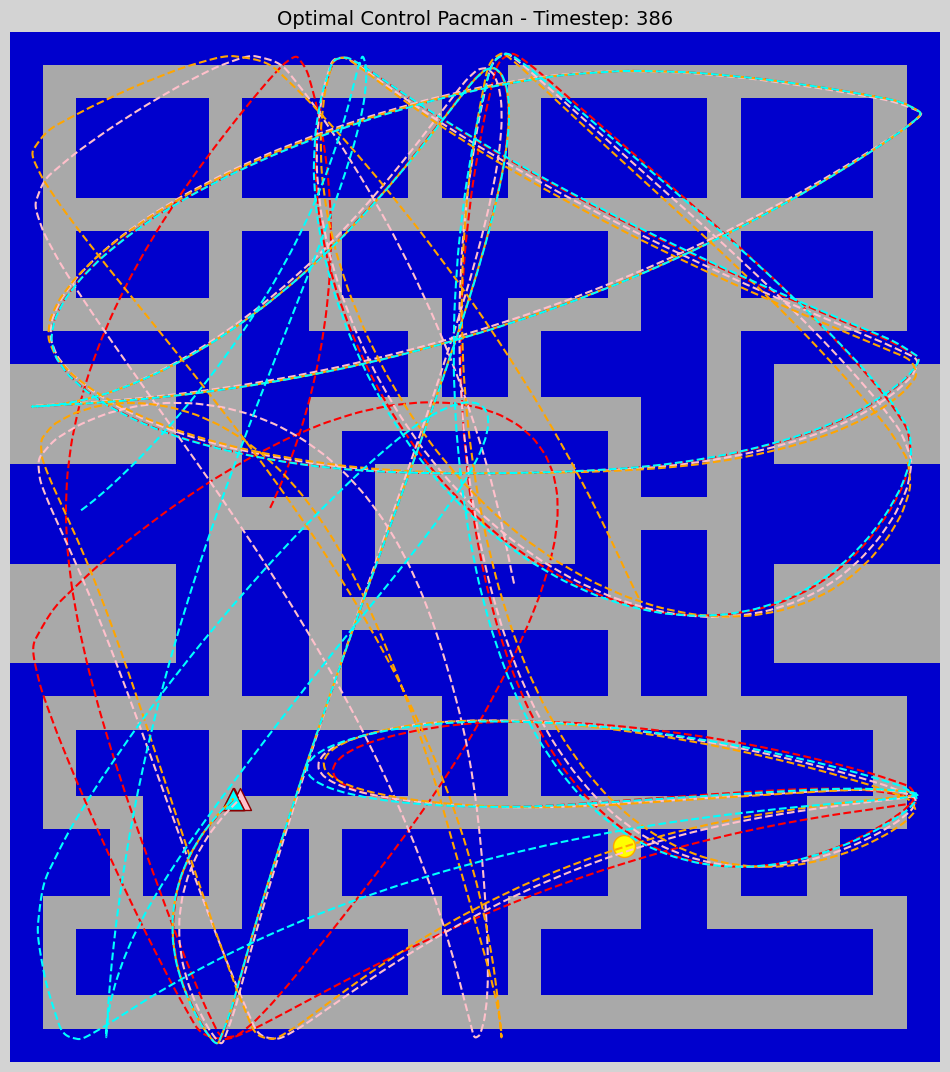

In [119]:
animation_filename = "test"
game.play(plot=False)
game.save_animation(animation_filename, fps=8)

In [120]:
mp.ipython_display(f"{animation_filename}.mp4", width=600)
